# **MURD-ViT**: Urban Retrofitting Detection with Vision Transformer: Where, When, and What


This notebook implements a deep learning pipeline for detecting urban retrofitting using temporal street view images and demographic data. This is done by training a Vision Transformer (ViT) based model which integrates features from before/after temporal images of different locations with demographic data to classify urban retrofitting into five categories.

Follow along as we build a model from scratch. We’ll start by handling our Datasets, move into defining the Model Architecture, walk through Training and Validation, and wrap up by visualizing our Results.

## Background

Urban retrofitting refers to micro-scale interventions made within existing urban spaces to enhance its functionality, sustainability, and environmental friendliness. Rather than promoting large-scale re-construction of infrastructures and buildings, it focuses on upgrading existing infrastructures, improving transportation systems and densifying urban areas in correspondence with present developmental patterns. While these retrofits may seem small in isolation, their holistic impact at a larger scale can shape urban development trajectories and improve quality of life. Urban retrofitting presents an opportunity to rehabilitate existing spaces, resurrect capital, enhance mobility, reduce pollution and energy consumption, and promote green infrastructure thus, targeting social, economic, and environmental sustainability.

Let's see an example: Allegheny Mall, Pittsburgh before/after 2016 (Retrofitted into offices/residential)

<img alt= "Urban Retrofitting" src="data/figures_low/UR.png" width="700" height="250" />



Global cities have adopted diverse retrofitting strategies to enhance urban livability, efficiency, and sustainability through different key approaches:

1) **Re-inhabitation**—upgrading housing quality and socioeconomic conditions while promoting diversity;
2) **Re-building**—optimizing existing structures for community purposes and increased density;
3) **Re-transportation**—establishing interconnected, environmentally sustainable mobility networks;
4) **Re-capital**—fostering sustainable socioeconomic development.

Particularly, many cities in the Unites States, such as Charlotte of North Carolina, Austin of Texas, Pittsburgh of Pennsylvania, Meriden of Connecticut, have practiced major urban retrofitting in the past decade.

The detection of urban retrofitting is pivotal for policymakers, urban planners and environmental scientists for better urban planning, assessing its environmental impact and enhancing urban residents’ well-being. However, there is no existing scalable approach for systematically automating the process of urban retrofitting detection. While major urban changes, such as new building construction, vegetation and  greenspace dynamics, road network modifications, land use and land cover transitions, and citywide growth patterns can be effectively detected using satellite remote sensing imagery, it falls short in identifying urban retrofitting. Urban retrofitting typically involves microscale interior changes in an urban space, which are difficult to capture using satellite images as they lack the circumstantial details and offer exterior and top view of the scenes. Other indirect indicators include survey based socioeconomic data, government open data like construction permits, which do not have sufficient locational and temporal frequency, differ in format, definitions and data processing methods across countries or administrative units and are not always globally available, limiting its scalability. To address this challenge, this paper shifts toward proximate remote sensing methods and integrates street view data and demographic data for urban retrofitting detection. Unlike satellites imagery offering the top view of urban areas, proximate remote sensing methods such as street view images, not only offer facade view of the objects in an urban space, but also provide high resolution and temporally frequent images recording horizontal scenes of streets and hence, are ideal for detecting micro adjustments brought to an urban environment.

This study presents a multimodal deep learning framework for urban retrofitting detection using large-scale street view data and demographic data. In particular, we collected large-scale Google Street View (GSV) imagery and demographic data from 2013 to 2023 in Mecklenburg County, North Carolina, where the city of Charlotte is located, for urban retrofitting detection. A computationally efficient deep learning model named MURD-ViT is developed for urban retrofitting detection capable of identifying where, when, and what type of urban retrofitting has occurred in the city, while demonstrating robust performance across different spatiotemporal context and urban retrofitting categories: re-inhabitation, re-building, re-transportation, and re-capital. This study introduces the first model for the automated detection of urban retrofitting, which has successfully identified retrofitting initiatives with robust performance. The proposed MURD-ViT provides a tool for urban planners and policymakers to assess urban transformation trends over decades and support evidence-based planning and decision making.



## Table of Contents
1. [Installation and Setup](#installation)
2. [Dataset](#dataset)
3. [Model Architecture](#architecture)
4. [Training and Validation Functions](#training)\
   [File Configuration and Set Hyperparameters](#config)
5. [Data Loading and Preprocessing](#data-loading)
6. [Model Training](#inference)
7. [Load GPU Trained Weights](#load-trained-weights)
8. [Evaluation and Prediction Results](#eval-results)
9. [Conclusion](#conclusion)
10. [Limitations and Future Direction](#limitations)

##  1. <a id="installation">Installation and Setup </a>

Install required Python packages for deep learning, computer vision, and geospatial anlytics.

This entire workflow requires the core python dependencies: torch torchvision timm pandas geopandas numpy opencv-python scikit-learn matplotlib folium openpyxl.
The specific dependencies used are provided in requirements.txt.

For now, we can use `geoai` kernel of I-GUIDE Platform and install packages on top of that.

In [2]:
# NOTE: When geoai Kernel is used.
# %pip install --no-cache-dir timm==1.0.15 geopandas==1.0.1 opencv-python==4.11.0.86 openpyxl==3.1.5

# NOTE: When geoai-Python3 Kernel is used.
# %pip install --no-cache-dir openpyxl==3.1.5

Now let's import all dependencies

In [3]:
# Import all necessary libraries for data processing, model training, visualization, and geospatial operations.

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
import torchvision.transforms as T
import timm
import pandas as pd
import geopandas as gpd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
import folium
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from datetime import datetime
import logging
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

/home/raj/Thesis/thesis_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Device Configuration

Set the computation device (CUDA GPU or CPU) for PyTorch operations.


In [ ]:
# set the device for torch backend
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [5]:
device = torch.device('cpu')
device

device(type='cpu')

##  2. <a id="dataset"> Dataset </a>

The study area focuses on Mecklenburg County, North Carolina, where the city of Charlotte is located. This study used an inclusive time-series dataset of GSV images collected to assess various forms of urban retrofitting occurring in Mecklenburg County. In conjunction with street view images, we collected yearly demographic data specifically-population counts from 2013 to 2023, for every census tract block group in Mecklenburg County, North Carolina from Census Bureau Data Portal (https://data.census.gov/).

<img alt= "Urban Retrofitting across Charlotte, NC." src="data/figures_low/UR_SVI.png" width="1100" height="650" />

**Figure**: Distribution of different retrofits across Census Block Groups in Mecklenburg County, NC and showcase of street view image pairs from sample locations mapped to an urban retrofitting category.

In particular, the street view images data collection involved selecting 10 random locations within each of the 555 census block groups and retrieving all historical images facing four different directions at each location. This was done by using the Street View Image Metadata service to determine available historical images and their unique Panorama IDs, followed by Street View Static API request with specific Panorama ID for desired date and direction. The images, named after month and year, were arranged by hierarchical directory structure based on block group, location and direction. Each image was cross paired with every other image to make a temporal pair. We managed to use 7,376 pairs of Google Street view images from randomly selected different locations within 555 census block groups. The image dataset contained: 
- No Change with 5,580 pairs,
- Re-building with 962 pairs,
- Re-inhabitation with 528 pairs,
- Re-transportation with 225 pairs,
- Re-capital with 81 pairs.

<img alt= "Street View Image Locations, NC." src="data/figures_low/study_area.png" width="800" height="650" />

 An **excel sheet** consisting of `Census Blockgroups`, `Latitude`, `Longitude`, `Direction`, `Start Date` (Date before Retrofitting), `End Date` (Date after Retrofitting), `Retrofitting Type`, `Population Density Change` and `Change Percentage` is created acting as a guide to load image data and values for demographic components.

### 2.1. Custom Dataset Class

Define the `UrbanRetrofittingDataset` class that loads temporal image pairs (before/after) along with demographic features and labels. The dataset handles coordinate precision, image loading, and label encoding.


In [6]:
# Structure images, deomgraphic data and labels.

class UrbanRetrofittingDataset(Dataset):
    def __init__(self, excel_file, image_dir, transform=None):
        """
        Args:
            excel_file (str): Path to the Excel file with annotations.
            image_dir (str): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on an image pair.

        Returns:
            (start_image, end_image, socio_economic_data, label): Tuple containing the start and end images, socio-economic data, and the label for each sample.
        """
        
        self.data = pd.read_excel(excel_file, dtype={"Latitude": str, "Longitude": str})
        # maintains precision. Do not change this two step converesion.
        self.data = self.data.astype({"Latitude": np.longdouble, "Longitude": np.longdouble})
        self.image_dir = image_dir
        self.transform = transform
        self.label_encoder = LabelEncoder()
        self.data['Change'] = self.label_encoder.fit_transform(self.data['Change'])  # Encode labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        census_block = str(row['ID'])
        lat, lon, direction = row['Latitude'], row['Longitude'], row['Heading']
        start_date, end_date = row['Start'], row['End']
        pop_density_change = row['PopDen_Diff']
        change_percentage = row['PopDen_Diff_Percentage']
        label = row['Change']

        # Load image pair Do not use f{} formatting to add longdouble number
        start_image_path = os.path.join(self.image_dir, census_block,  str(lat)+"_"+str(lon)+"_"+str(direction), f"{pd.to_datetime(start_date).strftime('%b %Y')}.png")
        end_image_path = os.path.join(self.image_dir, census_block, str(lat)+"_"+str(lon)+"_"+str(direction), f"{pd.to_datetime(end_date).strftime('%b %Y')}.png")
        start_image = Image.open(start_image_path).convert('RGB')
        end_image = Image.open(end_image_path).convert('RGB')

        if self.transform:
            start_image = self.transform(start_image)
            end_image = self.transform(end_image)

        # demographic data
        socio_economic_data = torch.tensor([pop_density_change, change_percentage], dtype=torch.float32)

        return start_image, end_image, socio_economic_data, label

## 3. <a id="architecture">Model Architecture</a>

Our proposed MURD-ViT, first of its kind deep learning model for urban retrofitting detection, uses a Vision Transformer as its backbone. Vision Transformers have been shown to outperform state-of-the art convolutional architectures such as ResNet on various computer vision tasks by its ability to model global spatial dependencies, particularly when pre-trained on large-scale datasets (14-300 million images) and fine-tuned to specialized tasks with limited data samples. ViT is adapted from Transformer architecture primarily introduced for Natural Language Processing (NLP) by retaining only the encoder block. The input images are divided into fixed size patches, flattened and treated as tokens with added positional encodings, in analogy with words in NLP tasks. The figure below represents the overall architecture of the proposed MURD-ViT model. ViT backbone provides richer low dimensional embeddings of street view images. Demographic MLP undertakes population data and linearly transforms into richer representations. Feature Concatenation integrates the output features from the ViT backbone, and Demographic MLP, producing combined features which are passed to the new Classifier Head for further processing. The Classifier Head then performs linear transformations, applies activation function and dropout operation, and finally maps combined features to retrofit categories.

<img alt= "MURD-ViT Architecture" src="data/figures_low/architecture.png" width="1000" height="700" />

Now, let's implement the `ViTWithSocioEconomic` model that combines:
- Pretrained ViT for extracting image features from start and end images
- Difference features (end - start) to capture temporal changes
- Demographic data embedding
- Classification head for 5-class urban retrofitting detection


In [7]:
# Model architecture

class ViTWithSocioEconomic(nn.Module):
    def __init__(self, num_numeric_features, num_classes):
        super(ViTWithSocioEconomic, self).__init__()
        # Pretrained ViT model from timm library without classification head to get image embeddings.
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        img_embedding_dim = self.vit.num_features

        # Numeric features embedding
        self.numeric_embed = nn.Sequential(
            nn.Linear(num_numeric_features, 32),
            nn.ReLU(),
            nn.Linear(32, 32)
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(3 * img_embedding_dim + 32, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    # Forward pass
    def forward(self, start_image, end_image, numeric_feats):
        start_feat = self.vit(start_image)
        end_feat = self.vit(end_image)
        diff_feat = end_feat - start_feat
        numeric_feat = self.numeric_embed(numeric_feats)
        combined = torch.cat([start_feat, end_feat, diff_feat, numeric_feat], dim=1)
        return self.classifier(combined)

## 4. <a id="training">Training and Validation Functions</a>

### 4.1 Training Function

Implement the training loop with per-class accuracy and loss tracking. This function processes batches, computes gradients, and updates model parameters while monitoring performance metrics for each class.


In [8]:
# Training function with per-class accuracy and loss tracking

def train_epoch(model, loader, criterion, optimizer, device, num_classes):
    model.train()
    total_samples = 0
    running_loss = 0.0
    correct_total = 0
    
    class_correct = [0] * num_classes
    class_total = [0] * num_classes
    class_losses = [0.0] * num_classes
    
    for start_imgs, end_imgs, socio_econ, labels in loader:
        start_imgs, end_imgs = start_imgs.to(device), end_imgs.to(device)
        socio_econ, labels = socio_econ.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(start_imgs, end_imgs, socio_econ)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

        preds = outputs.argmax(dim=1)
        correct_total += (preds == labels).sum().item()

        for cls in range(num_classes):
            cls_mask = labels == cls
            if cls_mask.sum() > 0:
                cls_outputs = outputs[cls_mask]
                cls_labels = labels[cls_mask]
                class_losses[cls] += criterion(cls_outputs, cls_labels).item() * cls_mask.sum().item()
                class_correct[cls] += (cls_outputs.argmax(dim=1) == cls_labels).sum().item()
                class_total[cls] += cls_mask.sum().item()

    epoch_loss = running_loss / total_samples
    overall_acc = 100 * correct_total / total_samples

    class_acc = [100 * class_correct[i] / class_total[i] if class_total[i] else 0 for i in range(num_classes)]
    class_avg_loss = [class_losses[i] / class_total[i] if class_total[i] else 0 for i in range(num_classes)]

    return epoch_loss, overall_acc, class_acc, class_avg_loss

### 4.2 Validation Function

Implement validation with top-2 accuracy metric. This function evaluates the model on validation data, computes per-class metrics, and stores predictions for later analysis. Top-2 accuracy considers a prediction correct if the true label is among the top 2 predicted classes.

The reason we implemented top2 predictions for validation is due to the nature of Urban Retrofitting; it itself is very rare thus, heavily dominated by No Change category rather than actual retrofit categories. In such scenario, it is standard practice to implement top2 predictions.


In [9]:
# Validation function with top-2 accuracy and per-class metrics

def validate_epoch(model, loader, criterion, device, num_classes):
    model.eval()
    total_samples = 0
    running_loss = 0.0
    correct_total = 0

    class_correct = [0] * num_classes
    class_total = [0] * num_classes
    class_losses = [0.0] * num_classes
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for start_imgs, end_imgs, socio_econ, labels in loader:
            start_imgs, end_imgs = start_imgs.to(device), end_imgs.to(device)
            socio_econ, labels = socio_econ.to(device), labels.to(device)

            outputs = model(start_imgs, end_imgs, socio_econ)
            loss = criterion(outputs, labels)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

            _, preds_top2 = outputs.topk(2, dim=1)
            correct_top2 = preds_top2.eq(labels.unsqueeze(1)).any(dim=1)
            stored_pred_batch = torch.where(correct_top2, labels, preds_top2[:, 0])

            all_preds.extend(stored_pred_batch.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            correct_total += correct_top2.sum().item()

            for cls in range(num_classes):
                cls_mask = labels == cls
                if cls_mask.sum() > 0:
                    cls_outputs = outputs[cls_mask]
                    cls_labels = labels[cls_mask]
                    class_losses[cls] += criterion(cls_outputs, cls_labels).item() * cls_mask.sum().item()
                    class_correct[cls] += correct_top2[cls_mask].sum().item()
                    class_total[cls] += cls_mask.sum().item()


    epoch_loss = running_loss / total_samples
    overall_acc = 100 * correct_total / total_samples

    class_acc = [100 * class_correct[i] / class_total[i] if class_total[i] else 0 for i in range(num_classes)]
    class_avg_loss = [class_losses[i] / class_total[i] if class_total[i] else 0 for i in range(num_classes)]

    return epoch_loss, overall_acc, class_acc, class_avg_loss, all_preds, all_labels

## <a id="config">Configuration and Hyperparameters</a>

Set up directories for checkpoints and logs, define model name, and configure hyperparameters including batch size, learning rate, number of epochs, and dataset paths.


In [27]:
# create a directory for saving and loading checkpoints.
RUN_SAMPLE = True # Set to False to run with full data.

# Hyperparameters
LEARNING_RATE = 0.0001
WEIGHT_DECAY_RATE = 0.00001
NUM_CLASSES = 5  # Five aspects of urban retrofitting

if RUN_SAMPLE:
    BATCH_SIZE = 8
    NUM_EPOCHS = 1

    # Dataset and DataLoader
    excel_File = "./data/Sample_data/labels.xlsx"
    image_dir = "./data/Sample_data/Streetview_data"

    # Number of clusters to form for Spatial Stratified Sampling.
    NO_OF_CLUSTERS = 4

    # Save model weights so, directory for storing checkpoints.
    checkpoint_dir = "Model_Checkpoints/Sample_Checkpoints"
    
else:
    # Following parameters were while training with full dataset on HPRC server.
    #  NOTE: Please see 7. Load GPU Trained Weights section for envrionment and resources details.
    BATCH_SIZE = 256
    NUM_EPOCHS = 30 

    # Dataset and DataLoader
    excel_File = "./data/Full_data/labels.xlsx"
    image_dir = "./data/Full_data/Streetview_data"

    # Number of clusters to form for Spatial Stratified Sampling.
    NO_OF_CLUSTERS = 20

    # Save model weights so, directory for storing checkpoints.
    checkpoint_dir = "Model_Checkpoints"

# Configure directories for checkpoint and logs
os.makedirs(checkpoint_dir, exist_ok=True)

MODEL_NAME = "MURD-ViT"
CHECKPOINT_PATH = f"{checkpoint_dir}/{MODEL_NAME}_epoch_1.pth"

# directory for storing logs
logs_dir = "logs"
os.makedirs(logs_dir, exist_ok=True)

LOG_FILE = f"{logs_dir}/{MODEL_NAME}.txt"

### Logging Configuration

Configure logging to write training progress to both a file and console for monitoring and debugging purposes.


In [11]:
# Configure logging to file and console

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        # Append mode
        logging.FileHandler(LOG_FILE, mode='a'),
        # Also print to console
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

## 5. <a id="data-loading">Data Loading and Preprocessing</a>

### 5.1 Data Transformations and Spatial Stratified Split

Load the dataset with appropriate transformations:
- **Training transforms**: Include data augmentation (random flips, rotations, color jitter) to improve generalization
- **Validation transforms**: Only resize and normalize (no augmentation)

Implement spatial stratified sampling to ensure:
- K-Means Clustering to create 20 clusters in full dataset.
- Geographic diversity: Samples are split across spatial clusters
- Class balance: Each cluster maintains proportional class distribution as well as 80-20 training test split.
- Reproducibility: Fixed random seed for consistent splits

The following figures shows spatial stratified sampling implemented in our full dataset.

<img alt= "Spatial Stratified Sampling" src="data/figures_low/stratified_spatial_sampling.png" width="1000" height="650" />



In [13]:
# Data Loading

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Data transformations

train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Spatial stratified sampling split function 

def spatial_stratified_split(dataset, val_ratio=0.2, n_clusters=10):
    """
    Perform spatial stratified sampling split and return PyTorch-compatible UrbanRetrofittingDataset subsets.
    NOTE: n_clusters = 4 included at least 1 sample per class in each cluster. 
    Args:
        df (pd.DataFrame): Raw dataframe loaded from Excel.
        image_dir (str): Path to the image directory.
        transform (callable): Torchvision transform for images.
        val_ratio (float): Ratio for validation split.
        n_clusters (int): Number of spatial clusters.

    Returns:
        train_dataset (Subset), val_dataset (Subset), label_encoder
    """
    df = dataset.data.copy()
    
    # Ensure correct types
    df = df.dropna(subset=['Latitude', 'Longitude'])

    # Spatial clustering
    coords = df[['Latitude', 'Longitude']].values
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df['Cluster'] = kmeans.fit_predict(coords)

    # Stratified sampling within each spatial cluster
    train_indices, val_indices = [], []

    for cluster in df['Cluster'].unique():
        cluster_df = df[df['Cluster'] == cluster]
        for label in cluster_df['Change'].unique():
            label_df = cluster_df[cluster_df['Change'] == label]
            n_val = max(1, int(len(label_df) * val_ratio))
            val_sample = label_df.sample(n=n_val, random_state=42)
            train_sample = label_df.drop(val_sample.index)
            train_indices.extend(train_sample.index)
            val_indices.extend(val_sample.index)

    # Reset index to use Subset
    df.reset_index(drop=True, inplace=True)

    dataset.data = df

    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs='EPSG:4326')

    return train_indices, val_indices, gdf

logger.info("Data Loading Initiated!")
# initializing dataset twice to use multiple transforms for training and validation.
train_dataset = UrbanRetrofittingDataset(excel_File, image_dir, train_transform)
val_dataset = UrbanRetrofittingDataset(excel_File, image_dir, val_transform)

# use any one to get train and val indices.
train_indices, val_indices, clusters_gdf = spatial_stratified_split(dataset=train_dataset, val_ratio=0.2, n_clusters=NO_OF_CLUSTERS)
_,_,_ = spatial_stratified_split(dataset=val_dataset, val_ratio=0.2, n_clusters=NO_OF_CLUSTERS)

train_dataset = Subset(train_dataset, train_indices)
val_dataset = Subset(val_dataset, val_indices)
logger.info("Split data into training and validation.")


2026-03-05 19:15:27,270 - INFO - Data Loading Initiated!


2026-03-05 19:15:27,325 - INFO - Split data into training and validation.


### 5.2 Dataset Distribution Logging

Log the distribution of classes in training and validation sets to verify balanced splits and understand data composition.


In [14]:
# Log cluster distribution

all_labels = train_dataset.dataset.data['Change']

def log_distribution(all_labels, dataset, name):
    label_counts = Counter([all_labels[i] for i in dataset.indices])
    label_encoder = dataset.dataset.label_encoder
    logger.info(f"{name} distribution:")
    for label_idx in sorted(label_counts):
        logger.info(f"\t{label_encoder.classes_[label_idx]}: {label_counts[label_idx]}")

log_distribution(all_labels, train_dataset, "Train")
log_distribution(all_labels, val_dataset, "Validation")

2026-03-05 19:15:29,730 - INFO - Train distribution:
2026-03-05 19:15:29,732 - INFO - 	No Change: 19
2026-03-05 19:15:29,733 - INFO - 	re-building: 17
2026-03-05 19:15:29,734 - INFO - 	re-capital: 3
2026-03-05 19:15:29,734 - INFO - 	re-inhabitation: 5
2026-03-05 19:15:29,735 - INFO - 	re-transportation: 8
2026-03-05 19:15:29,736 - INFO - Validation distribution:
2026-03-05 19:15:29,737 - INFO - 	No Change: 4
2026-03-05 19:15:29,738 - INFO - 	re-building: 3
2026-03-05 19:15:29,739 - INFO - 	re-capital: 1
2026-03-05 19:15:29,740 - INFO - 	re-inhabitation: 2
2026-03-05 19:15:29,741 - INFO - 	re-transportation: 2


### 5.3 Training Set Cluster Analysis

Display the distribution of samples across spatial clusters and classes in the training set. This helps verify that the spatial stratified split maintains class representation in each cluster.


In [15]:
# Summary of clusters and class distribution for training set

train_df = train_dataset.dataset.data.loc[train_indices]
counts = train_df.groupby(['Cluster', 'Change']).size().unstack(fill_value=0)
logger.info("Training Sample counts per class in each cluster:")
logger.info(f"\n{counts}")

2026-03-05 19:15:32,766 - INFO - Training Sample counts per class in each cluster:


2026-03-05 19:15:32,770 - INFO - 
Change    0   1  2  3  4
Cluster                 
0        12   7  3  0  8
1         0   0  0  3  0
2         7  10  0  0  0
3         0   0  0  2  0


### 5.4 Validation Set Cluster Analysis

Display the distribution of samples across spatial clusters and classes in the validation set to ensure proper validation coverage.


In [16]:
# Summary of clusters and class distribution for validation set

val_df = val_dataset.dataset.data.loc[val_indices]
counts = val_df.groupby(['Cluster', 'Change']).size().unstack(fill_value=0)
logger.info("Validation Sample counts per class in each cluster:")
logger.info(f"\n{counts}")

2026-03-05 19:15:34,536 - INFO - Validation Sample counts per class in each cluster:
2026-03-05 19:15:34,538 - INFO - 
Change   0  1  2  3  4
Cluster               
0        3  1  1  0  2
1        0  0  0  1  0
2        1  2  0  0  0
3        0  0  0  1  0


### 5.5 Spatial Stratified Sampling Locations Data Visualization

**Uncomment and run the following cells only if you run with full dataset.**


In [ ]:
# import matplotlib.cm as cm
# import matplotlib.colors as mcolors

# # Prepare colors for classes
# classes = train_dataset.dataset.label_encoder.classes_
# num_classes = len(classes)
# # colormap = cm.get_cmap('tab10', num_classes)
# # class_colors = {classes[i]: mcolors.rgb2hex(colormap(i)) for i in range(num_classes)}
# class_colors = {
#     'No Change': "#9caab6",
#     're-building': "#8243ab",
#     're-capital': '#2e8453',
#     're-inhabitation': '#08478c',
#     're-transportation': "#b82200"
# }

# # Get cluster polygons (convex hull)
# cluster_polys = clusters_gdf[['Cluster', 'geometry']].dissolve(by='Cluster', as_index=False, aggfunc='first')
# cluster_polys['geometry'] = cluster_polys.geometry.convex_hull
# cluster_polys = gpd.GeoDataFrame(cluster_polys, geometry="geometry", crs='EPSG:4326')
# cluster_polys.rename(columns={0: 'geometry'}, inplace=True)

# # Function to build dynamic map to view clusters and locations using folium.
# def create_folium_cluster_map(data_gdf, class_colors, title):
#     m = folium.Map(location=[data_gdf['Latitude'].mean(), data_gdf['Longitude'].mean()], tiles="Cartodb Positron", zoom_start=11, zoom_control=False)
    
#     # Plot clusters (polygons)
#     for _, row in cluster_polys.iterrows():
#         folium.GeoJson(
#             row['geometry'],
#             style_function=lambda feature, clr=row['Cluster']: {
#                 'fillColor': "#e7e7e7",
#                 'color': 'black',
#                 'weight': 1,
#                 'fillOpacity': 0.8
#             },
#             tooltip=f"Cluster {row['Cluster']}"
#         ).add_to(m)

#     # Add class samples as points
#     for _, row in data_gdf.iterrows():
#         cls = row['Change']
#         color = class_colors[classes[cls]]
#         popup = f"Class: {cls}<br>Cluster: {row['Cluster']}"
#         folium.CircleMarker(
#             location=[row['Latitude'], row['Longitude']],
#             radius=2.5,
#             color="white",      # Outline color
#             weight=0.5,           # Outline thickness
#             fill=True,
#             fill_color=color,
#             fill_opacity=1,
#             popup=popup
#         ).add_to(m)

#     # Add legend
#     legend_html = "<div style='position: fixed; top: 20px; right: 20px; z-index: 9999; background-color: white; padding: 10px; border: 1px solid #ccc;'>"
#     legend_html += "<b>Retrofit Category</b><br>"
#     for cls, color in class_colors.items():
#         legend_html += f"<i style='background:{color}; width:10px;height:10px;display:inline-block;border-radius:50%;'></i> {cls}<br>"
#     legend_html += "</div>"
#     m.get_root().html.add_child(folium.Element(legend_html))
#     # # Add the Fullscreen plugin to the map
#     # Fullscreen().add_to(m)
#     return m

# # Generate and save maps
# train_map = create_folium_cluster_map(train_df, class_colors, "Training Data Map")
# val_map = create_folium_cluster_map(val_df, class_colors, "Validation Data Map")

In [ ]:
# # visualize training set map.
# train_map

In [ ]:
# # visualize validation set map. 
# val_map

### Training Set DataFrame Display

Display the training dataset DataFrame for inspection of data structure and content.


In [17]:
# display traing set dataframe.
train_df

,ID,Latitude,Longitude,Heading,Start,End,Change,PopDen_Diff,PopDen_Diff_Percentage,Cluster
0,371190001001,35.219878,-80.852954,0,2014-05-01,2015-03-01,0,195.615409,11.800487,2
6,371190001001,35.221657,-80.852021,0,2014-05-01,2015-07-01,0,195.615409,11.800487,2
7,371190001001,35.221657,-80.852021,90,2017-04-01,2018-04-01,0,615.079378,28.424977,2
8,371190001001,35.221657,-80.852021,180,2014-05-01,2015-07-01,0,195.615409,11.800487,2
11,371190001001,35.221657,-80.852021,270,2016-03-01,2017-04-01,0,-239.981790,-9.983221,2
16,371190001001,35.221795,-80.850877,0,2021-06-01,2022-09-01,0,1353.711448,13.783689,2
19,371190001001,35.221795,-80.850877,270,2016-02-01,2016-12-01,0,0.000000,0.000000,2
1,371190001001,35.219878,-80.852954,0,2015-03-01,2016-03-01,1,550.546459,29.706202,2
2,371190001001,35.219878,-80.852954,0,2019-02-01,2021-05-01,1,6364.567011,184.130918,2
3,371190001001,35.219878,-80.852954,180,2019-02-01,2021-05-01,1,6364.567011,184.130918,2


### Validation Set DataFrame Display

Display the validation dataset DataFrame for inspection of data structure and content.


In [18]:
# display validation set dataframe.
val_df

,ID,Latitude,Longitude,Heading,Start,End,Change,PopDen_Diff,PopDen_Diff_Percentage,Cluster
4,371190001001,35.219878,-80.852954,270,2015-03-01,2016-03-01,0,550.546459,29.706202,2
17,371190001001,35.221795,-80.850877,90,2018-03-01,2019-03-01,1,677.595642,24.383164,2
15,371190001001,35.221795,-80.850877,0,2019-03-01,2021-06-01,1,6364.567011,184.130918,2
43,371190001002,35.230017,-80.846622,270,2018-03-01,2019-03-01,0,139.298685,1.207729,0
48,371190001002,35.231122,-80.847268,270,2016-04-01,2017-04-01,0,-161.586475,-1.469098,0
20,371190001001,35.229260,-80.846420,0,2014-05-01,2015-03-01,0,195.615409,11.800487,0
22,371190001001,35.229260,-80.846420,0,2018-03-01,2019-03-01,2,677.595642,24.383164,0
31,371190001002,35.229649,-80.847122,90,2014-05-01,2015-03-01,1,1036.382218,12.054439,0
53,371190001002,35.231590,-80.847864,270,2018-03-01,2020-03-01,4,373.320476,3.236715,0
37,371190001002,35.230017,-80.846622,0,2019-03-01,2020-03-01,4,234.021791,2.004773,0


### 5.6 Class Weights for Sampling

Compute class weights for the weighted random sampler to address class imbalance during training. These weights ensure that underrepresented classes are sampled more frequently during training.


In [21]:
# Extract labels from training dataset
all_labels = train_dataset.dataset.data['Change'] 
train_labels = [all_labels[i] for i in train_dataset.indices]
num_classes = len(set(train_labels))

# Compute class sample weights
# class_counts = np.array([train_labels.count(i) for i in range(num_classes)])
# class_weights_sampler = 1. / class_counts

# Class sample weights calculated manually to avoid extreme weights for very rare classes.
class_weights_sampler = np.array([0.0036, 0.0034, 0.0150, 0.0050, 0.0060])
sample_weights = np.array([class_weights_sampler[label] for label in train_labels])

### 5.7 Weighted Random Sampler

Create a weighted random sampler that uses the computed class weights to balance the training data during batch creation. This helps the model learn from all classes more evenly.


In [22]:
# Weighted sampler for drawing training samples.
sampler = WeightedRandomSampler(weights=sample_weights,
                                 num_samples=len(sample_weights),
                                 replacement=True)

### 5.8 Class Weights for Loss Function

Compute class weights for the loss function to penalize misclassifications of rare classes more heavily. This helps the model focus on learning underrepresented classes during optimization.


In [23]:

# Compute class weights for loss function.
# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(labels),
#     y=labels
# )

# Manually experimented class weights to avoid extreme weights for very rare classes.
class_weights = np.array([1.66, 7.22, 5.56, 9.22, 9.34])

weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
logger.info("Class weights used for loss function:")
for label, weight in zip(train_dataset.dataset.label_encoder.classes_, class_weights):
    logger.info(f"\tClass {label}: Weight={weight:.4f}")

2026-03-05 19:21:15,364 - INFO - Class weights used for loss function:
2026-03-05 19:21:15,366 - INFO - 	Class No Change: Weight=1.6600
2026-03-05 19:21:15,367 - INFO - 	Class re-building: Weight=7.2200
2026-03-05 19:21:15,367 - INFO - 	Class re-capital: Weight=5.5600
2026-03-05 19:21:15,368 - INFO - 	Class re-inhabitation: Weight=9.2200
2026-03-05 19:21:15,369 - INFO - 	Class re-transportation: Weight=9.3400


### 5.9 Data Loading Workers Configuration (Used later when GPU is available)

Determine the optimal number of worker processes for parallel data loading. Using multiple workers speeds up data preprocessing and loading during training.


In [24]:
# to enable faster data loading using multiple workers for data loading.
import multiprocessing
num_workers = multiprocessing.cpu_count() // 2
num_workers

12

### 5.10 DataLoader Initialization

Create PyTorch DataLoaders for training and validation sets with:
- Batch size configuration
- Weighted sampling for training (to handle class imbalance)
- Multiple workers for parallel data loading
- Pinned memory for faster GPU transfer


In [25]:
# Data Loaders.
if device.type == 'cuda':
    logger.info(f"Using Cuda. Batch Size: {BATCH_SIZE}, Workers: {num_workers}, pin_memory: True, LR: {LEARNING_RATE}, Wt. Decay: {WEIGHT_DECAY_RATE}")# this will be a lazy loader. Just initialization happens here. Real work happens inside for loop of data loader.
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=num_workers, pin_memory=True)
    logger.info("Training Loader is now ready!")
    
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)
    logger.info("Validation Loader is now ready!")
else:
    logger.info(f"Using CPU. Batch Size: {BATCH_SIZE}, LR: {LEARNING_RATE}, Wt. Decay: {WEIGHT_DECAY_RATE}")# this will be a lazy loader. Just initialization happens here. Real work happens inside for loop of data loader.
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
    logger.info("Training Loader is now ready!")
    
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    logger.info("Validation Loader is now ready!")

2026-03-05 19:21:22,487 - INFO - Using CPU. Batch Size: 8, LR: 0.0001, Wt. Decay: 1e-05
2026-03-05 19:21:22,489 - INFO - Training Loader is now ready!
2026-03-05 19:21:22,491 - INFO - Validation Loader is now ready!


## 6. <a id="inference">Model Training</a>

Initialize the model, loss function, and optimizer. The training loop:
- Trains the model for specified number of epochs
- Validates after each epoch.
- Logs per-class and overall metrics
- Saves checkpoints and supports resuming from checkpoints if training is interrupted.

For short runtime only one epoch was set in [File Configuration and Set Hyperparameters](#config)


In [26]:
# Inference

# Model, Loss, Optimizer
model = ViTWithSocioEconomic(2, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY_RATE)

# Load checkpoint if exists
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False) if device.type == "cuda" else torch.load(CHECKPOINT_PATH, weights_only=False, map_location=device) # Target CPU in this case. 
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    train_acc_per_class = checkpoint['train_acc_per_class']
    val_acc_per_class = checkpoint['val_acc_per_class']
    train_loss_per_class = checkpoint['train_loss_per_class']
    val_loss_per_class = checkpoint['val_loss_per_class']
    overall_train_acc = checkpoint['overall_train_acc']
    overall_val_acc = checkpoint['overall_val_acc']
    overall_train_loss = checkpoint['overall_train_loss']
    overall_val_loss = checkpoint['overall_val_loss']
    
    val_preds = checkpoint['val_preds']
    val_labels = checkpoint['val_labels']
    
    logger.info(f"Loaded checkpoint from epoch {start_epoch}")
else:
    # Initialize lists to store losses and accuracies
    start_epoch = 0
    train_acc_per_class = []
    val_acc_per_class = []
    train_loss_per_class = []
    val_loss_per_class = []
    overall_train_acc = []
    overall_val_acc = []
    overall_train_loss = []
    overall_val_loss = []
    val_preds = None
    val_labels = None

    logger.info("No checkpoint found - starting new training")

for epoch in range(start_epoch, NUM_EPOCHS):
    train_loss, train_overall_acc,  train_class_acc, train_class_loss = train_epoch(model, train_loader, criterion, optimizer, device, NUM_CLASSES)
    val_loss, val_overall_acc, val_class_acc, val_class_loss, val_preds, val_labels  = validate_epoch(model, val_loader, criterion, device, NUM_CLASSES)
    
    train_acc_per_class.append(train_class_acc)
    val_acc_per_class.append(val_class_acc)
    train_loss_per_class.append(train_class_loss)
    val_loss_per_class.append(val_class_loss)
    overall_train_acc.append(train_overall_acc)
    overall_val_acc.append(val_overall_acc)
    overall_train_loss.append(train_loss)
    overall_val_loss.append(val_loss)

    logger.info(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    logger.info(f"Train Accuracy: {train_overall_acc:.2f}%")
    logger.info(f"Train Loss: {train_loss:.4f}")
    for idx, cls in enumerate(train_dataset.dataset.label_encoder.classes_):
        logger.info(f"\tTrain Class '{cls}': Acc={train_class_acc[idx]:.2f}%, Loss={train_class_loss[idx]:.4f}")
    
    logger.info(f"Validation Accuracy: {val_overall_acc:.2f}%")
    logger.info(f"Validation Loss: {val_loss:.4f}")
    for idx, cls in enumerate(train_dataset.dataset.label_encoder.classes_):
        logger.info(f"\tVal Class '{cls}': Acc={val_class_acc[idx]:.2f}%, Loss={val_class_loss[idx]:.4f}")

    # Save checkpoints after every epoch with all relevant information for resuming training or analysis.
    CHECKPOINT_PATH = os.path.join(checkpoint_dir, f"{MODEL_NAME}_epoch_{epoch+1}.pth")
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_acc_per_class': train_acc_per_class,
        'val_acc_per_class': val_acc_per_class,
        'train_loss_per_class': train_loss_per_class,
        'val_loss_per_class': val_loss_per_class,
        'overall_train_acc':overall_train_acc,
        'overall_val_acc':overall_val_acc,
        'overall_train_loss':overall_train_loss,
        'overall_val_loss':overall_val_loss,
        'val_preds': val_preds,
        'val_labels': val_labels

    }, CHECKPOINT_PATH)
    logger.info(f"Saved checkpoint to {CHECKPOINT_PATH}")

    logger.info("-"*100)
logger.info("Done with Inference.")

2026-03-05 19:21:36,687 - INFO - Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2026-03-05 19:21:37,272 - INFO - [timm/vit_base_patch16_224.augreg2_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2026-03-05 19:21:37,649 - INFO - No checkpoint found - starting new training
2026-03-05 19:22:12,383 - INFO - Epoch 1/1
2026-03-05 19:22:12,386 - INFO - Train Accuracy: 15.38%
2026-03-05 19:22:12,388 - INFO - Train Loss: 11.2833
2026-03-05 19:22:12,389 - INFO - 	Train Class 'No Change': Acc=0.00%, Loss=9.1518
2026-03-05 19:22:12,390 - INFO - 	Train Class 're-building': Acc=37.50%, Loss=20.9672
2026-03-05 19:22:12,391 - INFO - 	Train Class 're-capital': Acc=0.00%, Loss=6.5034
2026-03-05 19:22:12,393 - INFO - 	Train Class 're-inhabitation': Acc=0.00%, Loss=2.9840
2026-03-05 19:22:12,393 - INFO - 	Train Class 're-transportation': Acc=25.00%, Loss=2.2371
2026-03-05 19:

## 7. <a id="load-trained-weights">Load trained weights of the model before evaluation and results</a>

- The training of the proposed MURD-ViT model exploited high performance computing (HPC) resources from an advanced computational server-Accelerating Computing for Emerging Sciences (ACES) computing clusters from Texas A&M High Performance Research Computing Center.
- MURD-ViT was trained on a single NVIDIA H100 94GB GPU node with 32 cores.
- The operating system was Red Hat Enterprise Linux 8.10. Model training takes approximately 1 hour, 22 minutes and 30 seconds in total for 30 epochs, resulting in 2 minutes 45 seconds per epoch.
- Additionally, MURD-ViT was optimized to minimize the computing costs, enabling it to run on low-end laptops and personal computers.

In [28]:
# path of the saved model weights.
CHECKPOINT_PATH = "Model_Checkpoints/MURD-ViT_weights.pth"

if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False) if device.type == "cuda" else torch.load(CHECKPOINT_PATH, weights_only=False, map_location=device) # Target CPU in this case. 
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    train_acc_per_class = checkpoint['train_acc_per_class']
    val_acc_per_class = checkpoint['val_acc_per_class']
    train_loss_per_class = checkpoint['train_loss_per_class']
    val_loss_per_class = checkpoint['val_loss_per_class']
    overall_train_acc = checkpoint['overall_train_acc']
    overall_val_acc = checkpoint['overall_val_acc']
    overall_train_loss = checkpoint['overall_train_loss']
    overall_val_loss = checkpoint['overall_val_loss']
    
    val_preds = checkpoint['val_preds']
    val_labels = checkpoint['val_labels']
    
    logger.info(f"Loaded model weights from MURD-VIT model atepoch {start_epoch}for evaluation.")
else:
    logger.info("No checkpoint found - cannot load model with the intended weights for evaluation.")

2026-03-05 19:24:42,829 - INFO - Loaded model weights from MURD-VIT model atepoch 30for evaluation.


## 8. <a id="eval-results">Evaluation and Results</a>

### 8.1 Classification Report and Confusion Matrix

Generate detailed classification metrics including:
- Precision, recall, and F1-score for each class
- Confusion matrix visualization showing prediction vs. actual labels
- Overall model performance summary


                   precision    recall  f1-score   support

        No Change     0.9566    0.9738    0.9651      1108
      re-building     0.8439    0.8022    0.8225       182
       re-capital     0.9333    0.8750    0.9032        32
  re-inhabitation     0.9394    0.9029    0.9208       103
re-transportation     0.9750    0.8667    0.9176        45

         accuracy                         0.9422      1470
        macro avg     0.9296    0.8841    0.9059      1470
     weighted avg     0.9415    0.9422    0.9416      1470



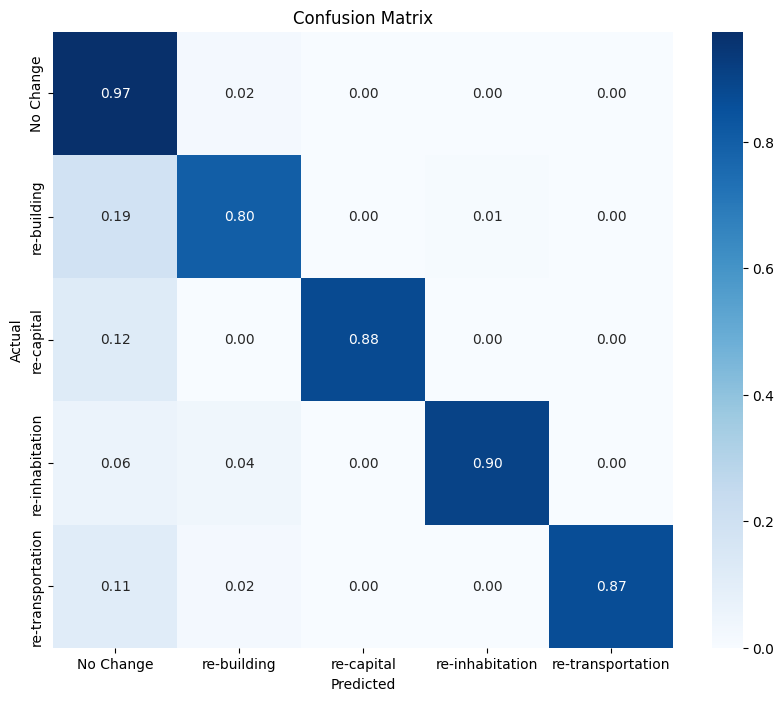

In [29]:
# Classification Report
classes = val_dataset.dataset.label_encoder.classes_
print(classification_report(val_labels, val_preds, target_names=classes, digits=4))

# Confusion Matrix
conf_matrix = confusion_matrix(val_labels, val_preds, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt=".2f", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### 8.2 Training Progress Visualization

Plot training and validation metrics over epochs:
- Per-class accuracy curves for training and validation
- Overall accuracy trends
- Helps identify overfitting, convergence, and class-specific performance patterns


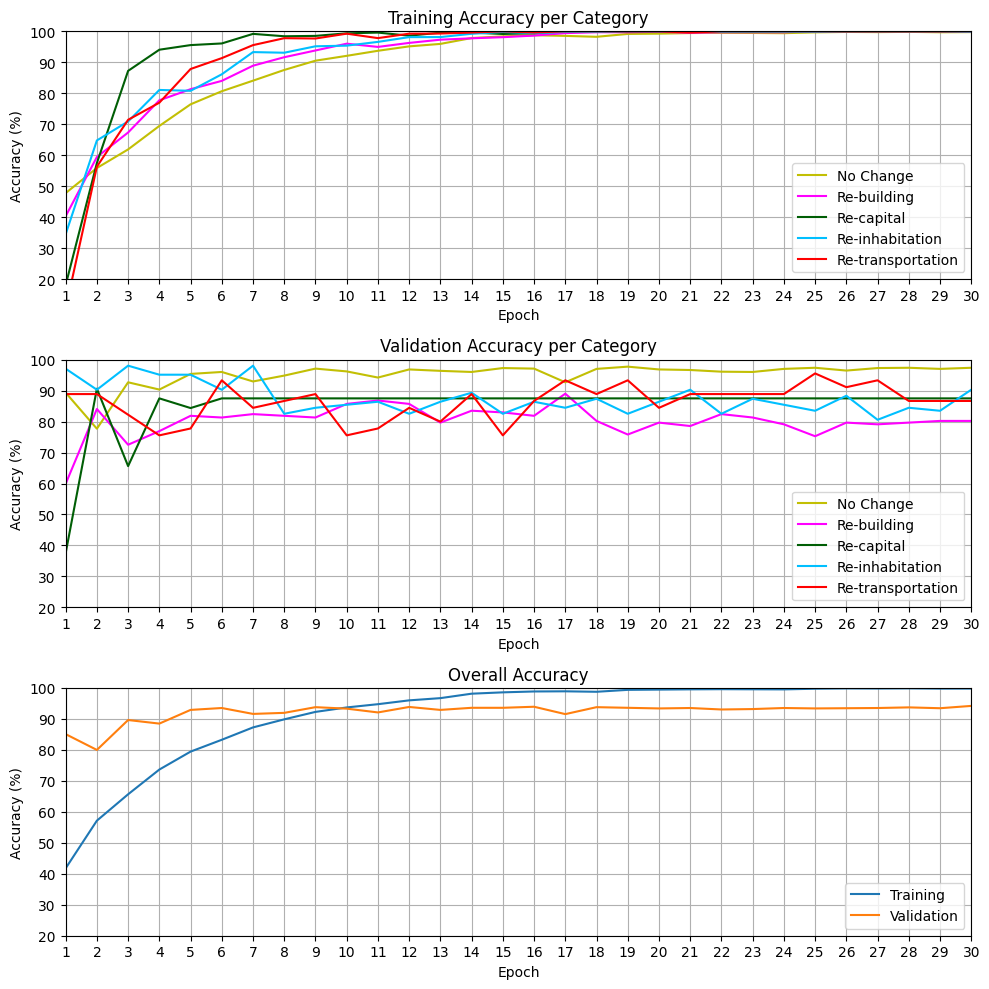

In [30]:
# visualize accuracy graphs.

import matplotlib.pyplot as plt

# Define class labels
classes = ['No Change', 'Re-building', 'Re-capital', 'Re-inhabitation', 'Re-transportation']

color_map = {
    'No Change': "#c2bf04",         # gold
    'Re-building': "#ff00ff",       # darkorange
    'Re-capital': "#005E05",        # magneta
    'Re-inhabitation': '#00bfff',   # red
    'Re-transportation': '#ff0000'  # deepskyblue
}

# Epochs
epochs = list(range(1, len(train_acc_per_class) + 1))

# Helper to convert list of lists to class-wise dict
def transpose_to_class_dict(data):
    return {cls: [epoch_data[i] for epoch_data in data] for i, cls in enumerate(classes)}

# Convert input lists to class-wise dicts
train_acc_class = transpose_to_class_dict(train_acc_per_class)
val_acc_class = transpose_to_class_dict(val_acc_per_class)
train_loss_class = transpose_to_class_dict(train_loss_per_class)
val_loss_class = transpose_to_class_dict(val_loss_per_class)

# Plotting
fig, axs = plt.subplots(3, 1, figsize=(10, 10))

# Training Accuracy per Class
for cls in classes:
    axs[0].plot(epochs, train_acc_class[cls], label=cls, color=color_map[cls])
axs[0].set_title('Training Accuracy per Category')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy (%)')
axs[0].set_xticks(epochs)
axs[0].set_xlim(1,30)
axs[0].set_ylim(20,100)
# axs[0].set_yticks(list(range(0,101,10))) 
axs[0].legend(loc='lower right')
axs[0].legend()

# Validation Accuracy per Class
for cls in classes:
    axs[1].plot(epochs, val_acc_class[cls], label=cls, color=color_map[cls])
axs[1].set_title('Validation Accuracy per Category')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].set_xticks(epochs)
axs[1].set_xlim(1,30)
axs[1].set_ylim(20,100)
axs[1].legend()

# Overall Accuracy
axs[2].plot(epochs, overall_train_acc, label='Training')
axs[2].plot(epochs, overall_val_acc, label='Validation')
axs[2].set_title('Overall Accuracy')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Accuracy (%)')
axs[2].set_xticks(epochs)
axs[2].set_xlim(1,30)
axs[2].set_ylim(20,100)
axs[2].legend()

# turn the grid on for every subplot
for ax in axs.ravel():
    ax.grid(True)
    ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 8.3 Prediction Visualization

Load the trained model and visualize sample predictions:
- Display correct and incorrect predictions for each class
- Show before/after image pairs with predicted labels and confidence scores
- Include metadata (census block, location, dates) for context


2026-03-05 19:24:55,201 - INFO - Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2026-03-05 19:24:55,247 - INFO - [timm/vit_base_patch16_224.augreg2_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


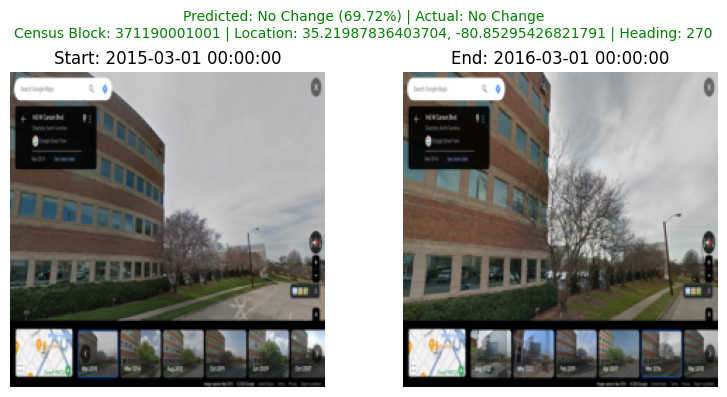

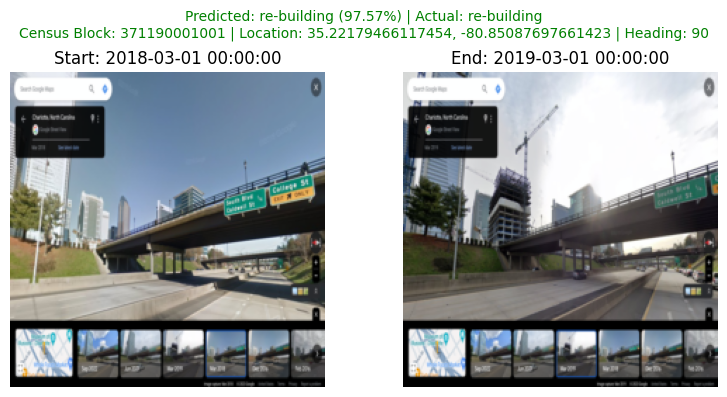

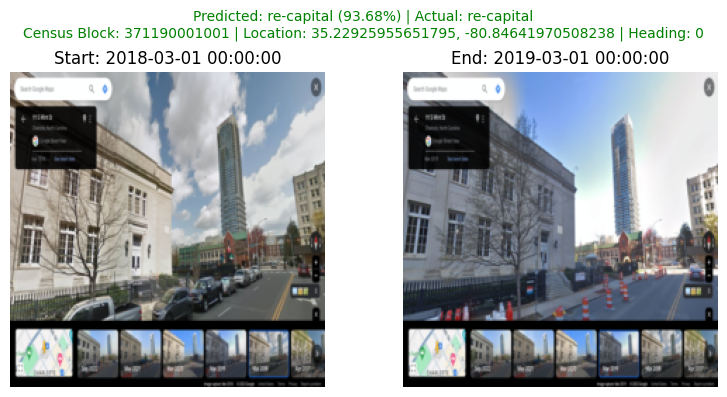

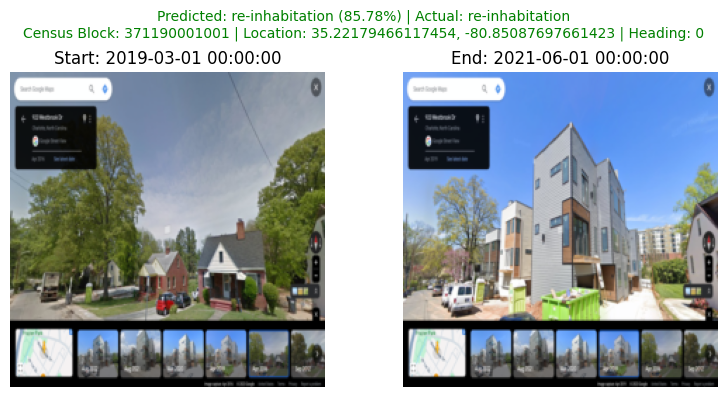

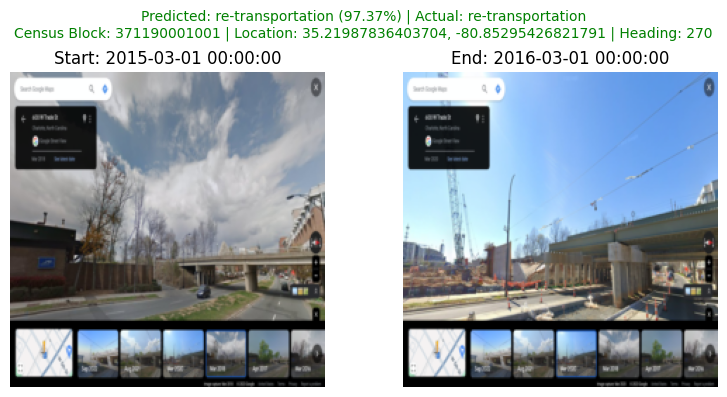

In [31]:
# visualize predictions of the model

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)

model = ViTWithSocioEconomic(2, NUM_CLASSES).to(device)
CHECKPOINT_PATH = "Model_Checkpoints/MURD-ViT_weights.pth"
checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

# Re-run validation to get all outputs
model.eval()
all_preds = []
all_labels = []
all_probs = []
all_paths = []

with torch.no_grad():
    for batch in val_loader:
        start_imgs, end_imgs, socio_econ, labels = batch
        start_imgs, end_imgs = start_imgs.to(device), end_imgs.to(device)
        socio_econ, labels = socio_econ.to(device), labels.to(device)
        
        outputs = model(start_imgs, end_imgs, socio_econ)
        probs = torch.softmax(outputs, dim=1)
        top_probs, preds = torch.max(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(top_probs.cpu().numpy())

        # Save for visualization
        for i in range(len(labels)):
            sample = val_dataset[i]  # since it's a Subset
            metadata = val_dataset.dataset.data.iloc[val_dataset.indices[i]]
            all_paths.append({
                'start_img': start_imgs[i].cpu(),
                'end_img': end_imgs[i].cpu(),
                'label': labels[i].item(),
                'pred': preds[i].item(),
                'confidence': top_probs[i].item(),
                'census_block': metadata['ID'],
                'lat': metadata['Latitude'],
                'lon': metadata['Longitude'],
                'heading': metadata['Heading'],
                'start_date': metadata['Start'],
                'end_date': metadata['End']
            })

# Organize samples by class
class_samples = {i: {'correct': [], 'incorrect': []} for i in range(NUM_CLASSES)}

for info in all_paths:
    cls = info['label']
    if info['pred'] == info['label']:
        if len(class_samples[cls]['correct']) < 1:
            class_samples[cls]['correct'].append(info)
    else:
        if len(class_samples[cls]['incorrect']) < 1:
            class_samples[cls]['incorrect'].append(info)

# Define label map
label_map = dict(enumerate(val_dataset.dataset.label_encoder.classes_))

# Plotting function
def plot_sample(info):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for i, (img, label) in enumerate(zip([info['start_img'], info['end_img']], ['Start', 'End'])):
        img = img.permute(1, 2, 0).numpy()
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # Unnormalize
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f"{label}: {info['start_date'] if label=='Start' else info['end_date']}")
        axes[i].axis('off')

    plt.suptitle(
        f"Predicted: {label_map[info['pred']]} ({info['confidence']*100:.2f}%) | Actual: {label_map[info['label']]}\nCensus Block: {info['census_block']} | Location: {info['lat']}, {info['lon']} | Heading: {info['heading']}",
        color='green' if info['pred'] == info['label'] else 'red',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

# Display 2 per class (correct + incorrect)
for cls in range(NUM_CLASSES):
    if class_samples[cls]['correct']:
        plot_sample(class_samples[cls]['correct'][0])
    if class_samples[cls]['incorrect']:
        plot_sample(class_samples[cls]['incorrect'][0])


### Take a look at comprehensive sample predictions of each category.

<img alt= "Model Prediction" src="data/figures_low/model_prediction.png" width="1400" height="1200" />


### 8.4 Export Predictions to Excel

Run inference on the validation dataset and save predictions to an Excel file. This includes:
- Original data columns
- Model predictions (encoded and label format)
- Enables further analysis and accuracy calculation by census block groups


In [33]:
# Store model's prediction for full dataset to an excel file from which accracy for each category across census blocks group can be calculated.

# Data Loading
# Dataset and DataLoader
# excel_File = "labels.xlsx"
# image_dir = "Streetview_data"
# BATCH_SIZE = 256
# NUM_CLASSES = 5
# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load entire dataset first with val_transform (no augmentation, just resizing and normalization)
full_dataset = UrbanRetrofittingDataset(excel_File, image_dir, val_transform)

# Get only validation subset using original val_indices
val_subset = Subset(full_dataset, val_indices)

data_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)

model = ViTWithSocioEconomic(2, NUM_CLASSES).to(device)
CHECKPOINT_PATH = "Model_Checkpoints/MURD-ViT_weights.pth"
checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

# Set model to eval mode
model.eval()

# Collect predictions and true labels
all_preds = []
all_true_labels = []

with torch.no_grad():
    for start_imgs, end_imgs, socio_econ, labels in data_loader:
        start_imgs = start_imgs.to(device)
        end_imgs = end_imgs.to(device)
        socio_econ = socio_econ.to(device)

        outputs = model(start_imgs, end_imgs, socio_econ)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

# Reload original Excel (to retain all original columns)
df = pd.read_excel(excel_File, dtype={"Latitude": str, "Longitude": str})
df = df.astype({"Latitude": np.longdouble, "Longitude": np.longdouble})
# filter validation rows only.
df = df.iloc[val_indices]

# Fit label encoder again to get label mappings
label_encoder = LabelEncoder()
df['Change_Encoded'] = label_encoder.fit_transform(df['Change'])

# Add predictions
df['Prediction'] = all_preds
df['Prediction_Label'] = label_encoder.inverse_transform(df['Prediction'].astype(int))

# Save to new Excel
output_excel = "data/val_dataset_predictions_for_mapping.xlsx"
df.to_excel(output_excel, index=False)

print(f"✅ Predictions for validation dataset saved to: {output_excel}")


2026-03-05 19:25:21,064 - INFO - Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2026-03-05 19:25:21,297 - INFO - [timm/vit_base_patch16_224.augreg2_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


✅ Predictions for validation dataset saved to: data/val_dataset_predictions_for_mapping.xlsx


### 8.5 Accuracy Calculation per Census Block Group (Contiues with Data exported from above.)

Calculate model accuracy metrics for each census block group:
- Overall accuracy per block group
- Per-class accuracy for each category
- Merge results with shapefile for geographic visualization
- Export as shapefile for GIS analysis and mapping


In [34]:
# Now, calculate accuracy for each category across census blocks group and merge with shapefile for model accuracy visualization.

import pandas as pd
import geopandas as gpd
import numpy as np

# Load files
excel_file = "data/val_dataset_predictions_for_mapping.xlsx"
shp_file = "data/Shapefile/mecklengburg_county_census_block_group_2013.shp"
output_shp = "data/Shapefile/accuracy_per_census_block_group.shp"

# Load Excel data
df = pd.read_excel(excel_file)

# Ensure ID is string for merge
df['ID'] = df['ID'].astype(str)

# List all unique true change categories in the dataset
all_categories = df['Change'].dropna().unique()

# Function to compute accuracy metrics per Census Block Group
def compute_accuracy(group):
    total = len(group)
    correct = (group['Change'] == group['Prediction_Label']).sum()
    overall_acc = round((correct / total) * 100, 2) if total else np.nan
    result = {'overall_accuracy': overall_acc}

    # Compute accuracy per category
    for category in all_categories:
        cat_group = group[group['Change'] == category]
        cat_total = len(cat_group)
        if cat_total:
            correct_cat = (cat_group['Change'] == cat_group['Prediction_Label']).sum()
            cat_acc = round((correct_cat / cat_total) * 100, 2)
        else:
            cat_acc = np.nan
        result[f'acc_{category}'] = cat_acc

    return pd.Series(result)

# Apply the accuracy function per Census Block Group
accuracy_by_id = df.groupby('ID').apply(compute_accuracy).reset_index()

# Load the shapefile
gdf = gpd.read_file(shp_file)

# Ensure GEOID is string for merging
gdf['GEOID'] = gdf['GEOID'].astype(str)

# Merge shapefile with accuracy data
merged_gdf = gdf.merge(accuracy_by_id, how='left', left_on='GEOID', right_on='ID')

# Identify accuracy columns (those starting with 'acc_' or 'overall_accuracy')
accuracy_cols = [col for col in merged_gdf.columns if col.startswith('acc_') or col == 'overall_accuracy']
print(accuracy_cols)
# Replace NaN with -9999 in only those columns
merged_gdf[accuracy_cols] = merged_gdf[accuracy_cols].fillna(-9999)

# Export the merged shapefile.
merged_gdf.to_file(output_shp)

/tmp/ipykernel_1669/1964803276.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  accuracy_by_id = df.groupby('ID').apply(compute_accuracy).reset_index()
/tmp/ipykernel_1669/1964803276.py:60: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged_gdf.to_file(output_shp)
/home/raj/Thesis/thesis_venv/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'overall_accuracy' to 'overall_ac'
  ogr_write(
/home/raj/Thesis/thesis_venv/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'acc_No Change' to 'acc_No Cha'
  ogr_write(
/home/raj/Thesis/thesis_venv/li

['overall_accuracy', 'acc_No Change', 'acc_re-building', 'acc_re-capital', 'acc_re-transportation', 'acc_re-inhabitation']


### Let's take a look at above exported shapefile. Here, an image is directly loaded because we don't get that many visualization flexibility as needed in python. But, this data can be easily visualized using geopandas and matplotlib in python.

<img alt="Model Prediction Accuracy" src="data/figures_low/prediction_accuracy.png" width="1100" height="750" />


## 9. <a id="conclusion"> Conclusion</a>

MURD-ViT represents the first multi-modal framework capable of detecting micro-scale urban retrofitting using temporal pairs of street view images and demographic data. The integration of these modalities, along with MURD-ViT’s architecture, enables the classification of retrofitting into five distinct categories. MURD-ViT shows strong predictive performance and generalizability across diverse urban scenes, suggesting its scalability to other cities undergoing rapid retrofitting changes.

The proposed MURD-ViT holds substantial potential for guiding urban transformations in a city through its ability to detect retrofits from temporal pairs of street view images and demographic data. Specifically, it can identify instances of urban retrofitting, categorize them into one of five changes, determine the period between changes and identify the location where these changes occur. MURD-ViT is trained on large-scale imagery comprising a diverse range of urban scenes. As a result, it exhibits strong proficiency in identifying retrofit categories in different urban environments, indicating promising scalability for application to other growing cities when trained with a relatively small but comprehensive set of samples. Urban planners and policymakers can leverage MURD-ViT to analyze patterns of urban transformation over decades, thereby devising future planning, policies and strategies. Identification of urban retrofits can help monitor urban renewal projects and evaluate their progress over time. Moreover, detecting urban retrofitting hotspots and coldspots can aid in assessing whether such practices benefit vulnerable population. Environmental experts may employ the retrofitting model to estimate their sustainability and revitalization efforts, delivering quantitative insights of retrofitting on urban resilience.



## 10.<a id="limitations"> Limitations and Future Direction</a>

Despite its promising performance, the study has some limitations. The training dataset is restricted to the study area and temporal range, possibly limiting MURD-ViT’s capability to other urban contexts. The demographic data used offers coarse spatial resolution as opposed to street view image locations within these block groups capturing local level heterogeneity. While MURD-ViT’s performance seems to illuminate retrofitting patterns within the study area, its applicability to other urban environments with different architectural styles and demographic structures will depend upon comprehensive nature of dataset collected and thus, remains untested in this study. Moreover, MURD-ViT occasionally struggles due to environmental factors like seasonal differences, lighting conditions, small-scale changes and visually similar objects.

Future efforts can address these limitations by incorporating larger and more diverse datasets from multiple study areas and time periods thus leading to make this a urban retrofitting foundational model. The integration of several higher resolution demographic indicators could further support MURD-ViT’s proficiency. Transfer learning and domain adaptation approaches may encourage MURD-ViT’s robustness when applied to different cities and urban environments. Also, MURD-ViT’s capacity could be expanded to detect broader range of urban transformations beyond those studied as part of the retrofitting problem.

Learn more at [GitHub Repo](https://github.com/GeoComputeLab/Spatial-AI-Challenge)